# PCOS Symptom-Only Screening — Random Forest

This notebook builds a **screening model** (not a diagnostic tool) for PCOS risk using
**only self-reportable fields** — no blood tests, hormone panels, or ultrasound.

Data source: `PCOS_data_without_infertility.xlsx` (Kottarathil, Kaggle — 541 patients, 10 hospitals in Kerala, India).

**Important framing:** the PCOS label in this dataset was assigned by clinicians using full
Rotterdam criteria (including ultrasound/labs). This model learns to predict *that diagnosis*
from a reduced, self-reportable feature set — it approximates the diagnostic outcome, it does
not itself apply Rotterdam criteria. Always present results as "risk indication — consult a
doctor", never as a diagnosis.

In [3]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    RocCurveDisplay
)

from imblearn.over_sampling import SMOTENC
from imblearn.pipeline import Pipeline

import joblib

sns.set_style("whitegrid")
pd.set_option("display.max_columns", 50)

In [4]:
df_raw = pd.read_excel(
    "../data/PCOS_data_without_infertility.xlsx",
    sheet_name="Full_new"
)

df_raw.columns = [c.strip() for c in df_raw.columns]

print(df_raw.shape)
df_raw.head(3)

(541, 45)


,Sl. No,Patient File No.,PCOS (Y/N),Age (yrs),Weight (Kg),Height(Cm),BMI,Blood Group,Pulse rate(bpm),RR (breaths/min),Hb(g/dl),Cycle(R/I),Cycle length(days),Marraige Status (Yrs),Pregnant(Y/N),No. of aborptions,I beta-HCG(mIU/mL),II beta-HCG(mIU/mL),FSH(mIU/mL),LH(mIU/mL),FSH/LH,Hip(inch),Waist(inch),Waist:Hip Ratio,TSH (mIU/L),AMH(ng/mL),PRL(ng/mL),Vit D3 (ng/mL),PRG(ng/mL),RBS(mg/dl),Weight gain(Y/N),hair growth(Y/N),Skin darkening (Y/N),Hair loss(Y/N),Pimples(Y/N),Fast food (Y/N),Reg.Exercise(Y/N),BP _Systolic (mmHg),BP _Diastolic (mmHg),Follicle No. (L),Follicle No. (R),Avg. F size (L) (mm),Avg. F size (R) (mm),Endometrium (mm),Unnamed: 44
0,1,1,0,28,44.6,152.0,19.300000,15,78,22,10.48,2,5,7.0,0,0,1.99,1.99,7.95,3.68,2.160326,36,30,0.833333,0.68,2.07,45.16,17.1,0.57,92.0,0,0,0,0,0,1.0,0,110,80,3,3,18.0,18.0,8.5,NaN
1,2,2,0,36,65.0,161.5,24.921163,15,74,20,11.70,2,5,11.0,1,0,60.80,1.99,6.73,1.09,6.174312,38,32,0.842105,3.16,1.53,20.09,61.3,0.97,92.0,0,0,0,0,0,0.0,0,120,70,3,5,15.0,14.0,3.7,NaN
2,3,3,1,33,68.8,165.0,25.270891,11,72,18,11.80,2,5,10.0,1,0,494.08,494.08,5.54,0.88,6.295455,40,36,0.900000,2.54,6.63,10.52,49.7,0.36,84.0,0,0,0,1,1,1.0,0,120,80,13,15,18.0,20.0,10.0,NaN


## Feature selection

Keeping only fields a user can answer **without any test, machine, or scan**.
Everything clinical (hormones, ultrasound follicle counts, blood pressure, blood group, vitals) is dropped.

In [5]:
KEEP_RAW = {
    "PCOS (Y/N)": "pcos",
    "Age (yrs)": "age",
    "Weight (Kg)": "weight_kg",
    "Height(Cm)": "height_cm",
    "Cycle(R/I)": "cycle_code",          # 2 = regular, 4/5 = irregular (raw dataset coding)
    "Cycle length(days)": "cycle_length_days",
    "Weight gain(Y/N)": "weight_gain",
    "hair growth(Y/N)": "hair_growth",
    "Skin darkening (Y/N)": "skin_darkening",
    "Hair loss(Y/N)": "hair_loss",
    "Pimples(Y/N)": "acne",
    "Fast food (Y/N)": "fast_food",
    "Reg.Exercise(Y/N)": "regular_exercise",
    "Hip(inch)": "hip_inch",
    "Waist(inch)": "waist_inch",
}

df = df_raw[list(KEEP_RAW.keys())].rename(columns=KEEP_RAW).copy()
print("Selected", len(df.columns) - 1, "features (+ target)")
df.head(3)


Selected 14 features (+ target)


,pcos,age,weight_kg,height_cm,cycle_code,cycle_length_days,weight_gain,hair_growth,skin_darkening,hair_loss,acne,fast_food,regular_exercise,hip_inch,waist_inch
0,0,28,44.6,152.0,2,5,0,0,0,0,0,1.0,0,36,30
1,0,36,65.0,161.5,2,5,0,0,0,0,0,0.0,0,38,32
2,1,33,68.8,165.0,2,5,0,0,0,1,1,1.0,0,40,36


## Cleaning & feature engineering

- `cycle_code` (2/4/5) -> `cycle_irregular` (0/1)
- Derive `bmi` from weight & height instead of keeping raw weight/height
- Derive `waist_hip_ratio` (optional field, self-measurable with a tape)
- Impute the handful of missing values (median for numeric, mode for binary)

In [6]:
df["cycle_irregular"] = (df["cycle_code"] != 2).astype(int)
df = df.drop(columns=["cycle_code"])

df["bmi"] = df["weight_kg"] / ((df["height_cm"] / 100) ** 2)
df["waist_hip_ratio"] = df["waist_inch"] / df["hip_inch"]

print("Missing values per column:")
print(df.isna().sum()[df.isna().sum() > 0])

for col in df.columns:
    if df[col].isna().any():
        if df[col].dropna().isin([0, 1]).all():
            df[col] = df[col].fillna(df[col].mode()[0])
        else:
            df[col] = df[col].fillna(df[col].median())

df["pcos"] = df["pcos"].astype(int)
print("\nFinal shape:", df.shape)
df.describe().T


Missing values per column:
fast_food    1
dtype: int64

Final shape: (541, 17)


,count,mean,std,min,25%,50%,75%,max
pcos,541.0,0.327172,0.469615,0.000000,0.000000,0.000000,1.000000,1.000000
age,541.0,31.430684,5.411006,20.000000,28.000000,31.000000,35.000000,48.000000
weight_kg,541.0,59.637153,11.028287,31.000000,52.000000,59.000000,65.000000,108.000000
height_cm,541.0,156.484835,6.033545,137.000000,152.000000,156.000000,160.000000,180.000000
cycle_length_days,541.0,4.940850,1.492020,0.000000,4.000000,5.000000,5.000000,12.000000
weight_gain,541.0,0.377079,0.485104,0.000000,0.000000,0.000000,1.000000,1.000000
hair_growth,541.0,0.273567,0.446202,0.000000,0.000000,0.000000,1.000000,1.000000
skin_darkening,541.0,0.306839,0.461609,0.000000,0.000000,0.000000,1.000000,1.000000
hair_loss,541.0,0.452865,0.498234,0.000000,0.000000,0.000000,1.000000,1.000000
acne,541.0,0.489834,0.500359,0.000000,0.000000,0.000000,1.000000,1.000000


## Exploratory look: class balance & symptom prevalence by PCOS status

pcos
0    364
1    177
Name: count, dtype: int64
pcos
0    0.673
1    0.327
Name: proportion, dtype: float64


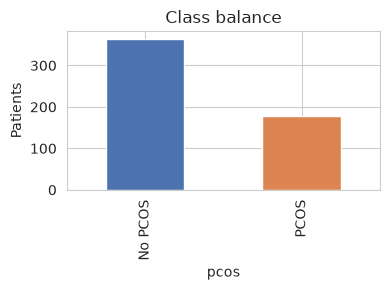

In [7]:
print(df["pcos"].value_counts())
print(df["pcos"].value_counts(normalize=True).round(3))

fig, ax = plt.subplots(figsize=(4, 3))
df["pcos"].value_counts().rename({0: "No PCOS", 1: "PCOS"}).plot(kind="bar", color=["#4C72B0", "#DD8452"], ax=ax)
ax.set_ylabel("Patients")
ax.set_title("Class balance")
plt.tight_layout()
plt.show()


                  No PCOS  PCOS
fast_food            38.5  78.5
acne                 39.0  69.5
weight_gain          22.8  68.4
skin_darkening       15.4  62.1
hair_loss            39.3  57.6
hair_growth          12.9  57.1
cycle_irregular      15.4  53.7
regular_exercise     22.8  28.8


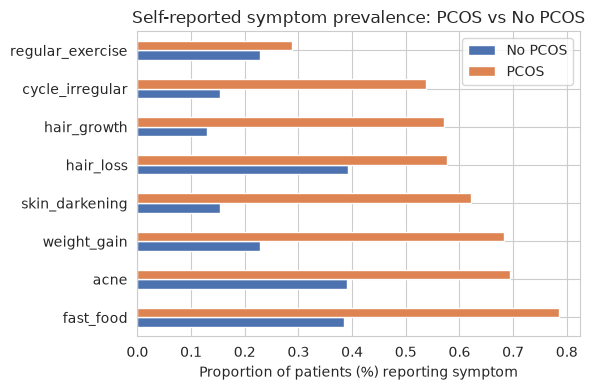

In [8]:
binary_symptoms = ["weight_gain", "hair_growth", "skin_darkening", "hair_loss",
                    "acne", "fast_food", "regular_exercise", "cycle_irregular"]

prevalence = df.groupby("pcos")[binary_symptoms].mean().T
prevalence.columns = ["No PCOS", "PCOS"]
prevalence = prevalence.sort_values("PCOS", ascending=False)
print((prevalence * 100).round(1))

prevalence.plot(kind="barh", figsize=(6, 4), color=["#4C72B0", "#DD8452"])
plt.xlabel("Proportion of patients (%) reporting symptom")
plt.title("Self-reported symptom prevalence: PCOS vs No PCOS")
plt.tight_layout()
plt.show()


## Train / test split

Stratified 80/20 split so the class ratio is preserved in both sets.

In [9]:
feature_cols = [c for c in df.columns if c != "pcos"]
X = df[feature_cols]
y = df["pcos"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
print("Train:", X_train.shape, " Test:", X_test.shape)


Train: (432, 16)  Test: (109, 16)


In [10]:
# Binary / categorical features for SMOTENC
categorical_features = [
    "weight_gain",
    "hair_growth",
    "skin_darkening",
    "hair_loss",
    "acne",
    "fast_food",
    "regular_exercise",
    "cycle_irregular"
]

# Convert feature names to column indices
categorical_indices = [
    feature_cols.index(col)
    for col in categorical_features
]

print("Feature columns:")
for i, col in enumerate(feature_cols):
    print(f"{i}: {col}")

print("\nCategorical features:")
for col, idx in zip(categorical_features, categorical_indices):
    print(f"{idx}: {col}")

Feature columns:
0: age
1: weight_kg
2: height_cm
3: cycle_length_days
4: weight_gain
5: hair_growth
6: skin_darkening
7: hair_loss
8: acne
9: fast_food
10: regular_exercise
11: hip_inch
12: waist_inch
13: cycle_irregular
14: bmi
15: waist_hip_ratio

Categorical features:
4: weight_gain
5: hair_growth
6: skin_darkening
7: hair_loss
8: acne
9: fast_food
10: regular_exercise
13: cycle_irregular


## Model: Random Forest + SMOTENC

SMOTENC is used to address class imbalance while preserving the
categorical/binary nature of self-reported symptom features.

Unlike vanilla SMOTE, SMOTENC does not create fractional values
for binary/categorical features.

SMOTENC is applied only within the training folds through an
imbalanced-learn Pipeline to avoid data leakage.

The Random Forest itself does not use `class_weight="balanced"` here,
so this experiment can be compared fairly against the original
class-weighted Random Forest baseline.

In [11]:
smotenc_rf_pipeline = Pipeline([
    (
        "smotenc",
        SMOTENC(
            categorical_features=categorical_indices,
            random_state=42
        )
    ),
    (
        "rf",
        RandomForestClassifier(
            n_estimators=300,
            max_depth=6,
            min_samples_leaf=4,
            random_state=42,
            n_jobs=-1
        )
    )
])

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# 5-fold CV — Recall
cv_recall = cross_val_score(
    smotenc_rf_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring="recall"
)

# 5-fold CV — ROC-AUC
cv_roc_auc = cross_val_score(
    smotenc_rf_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring="roc_auc"
)

print(
    f"5-fold CV recall (PCOS class): "
    f"{cv_recall.mean():.3f} +/- {cv_recall.std():.3f}"
)

print(
    f"5-fold CV ROC-AUC: "
    f"{cv_roc_auc.mean():.3f} +/- {cv_roc_auc.std():.3f}"
)

# Final training on complete training set
smotenc_rf_pipeline.fit(X_train, y_train)

print("\nSMOTENC + Random Forest trained successfully.")

5-fold CV recall (PCOS class): 0.752 +/- 0.060
5-fold CV ROC-AUC: 0.881 +/- 0.015

SMOTENC + Random Forest trained successfully.


## Evaluation on held-out test set

The test set is kept completely untouched by SMOTENC.
This provides an unbiased evaluation of the trained screening model.


              precision    recall  f1-score   support

     No PCOS       0.89      0.89      0.89        73
        PCOS       0.78      0.78      0.78        36

    accuracy                           0.85       109
   macro avg       0.83      0.83      0.83       109
weighted avg       0.85      0.85      0.85       109

ROC-AUC: 0.89


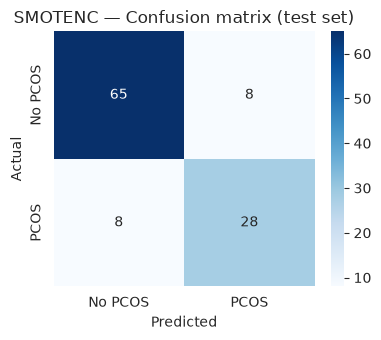

In [12]:
# Predictions on untouched test set
y_pred_smotenc = smotenc_rf_pipeline.predict(X_test)

# PCOS probability
y_proba_smotenc = smotenc_rf_pipeline.predict_proba(X_test)[:, 1]

# Classification report
print(
    classification_report(
        y_test,
        y_pred_smotenc,
        target_names=["No PCOS", "PCOS"]
    )
)

# ROC-AUC
smotenc_test_auc = roc_auc_score(
    y_test,
    y_proba_smotenc
)

print(
    "ROC-AUC:",
    round(smotenc_test_auc, 3)
)

# Confusion matrix
cm = confusion_matrix(
    y_test,
    y_pred_smotenc
)

fig, ax = plt.subplots(figsize=(4, 3.5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No PCOS", "PCOS"],
    yticklabels=["No PCOS", "PCOS"],
    ax=ax
)

ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title("SMOTENC — Confusion matrix (test set)")

plt.tight_layout()
plt.show()

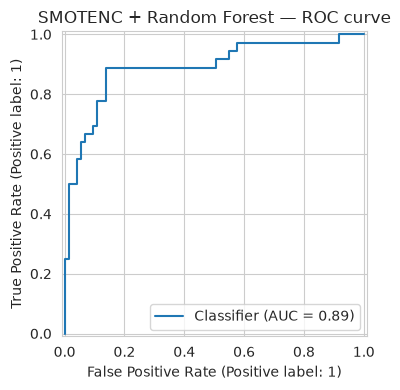

In [13]:
fig, ax = plt.subplots(figsize=(4.5, 4))

RocCurveDisplay.from_predictions(
    y_test,
    y_proba_smotenc,
    ax=ax
)

ax.set_title("SMOTENC + Random Forest — ROC curve")

plt.tight_layout()
plt.show()

## Feature importance

Which self-reported symptoms actually drive the model's predictions — useful both for
sanity-checking the model and for explaining a result to a user later.

skin_darkening       0.178
weight_gain          0.119
fast_food            0.118
cycle_length_days    0.115
hair_growth          0.086
waist_hip_ratio      0.050
acne                 0.050
age                  0.048
bmi                  0.041
cycle_irregular      0.039
weight_kg            0.037
height_cm            0.036
hip_inch             0.032
waist_inch           0.029
regular_exercise     0.013
hair_loss            0.010
dtype: float64


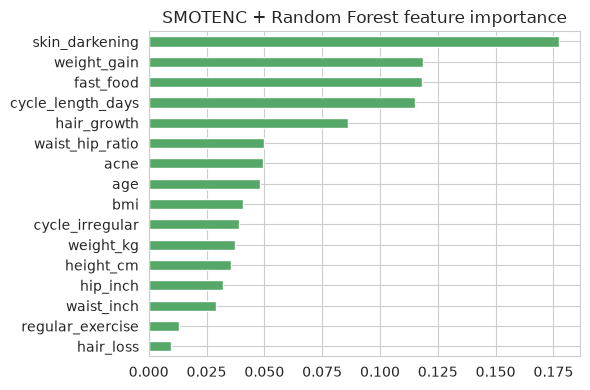

In [14]:
# Extract trained Random Forest from the pipeline
trained_rf = smotenc_rf_pipeline.named_steps["rf"]

importances = pd.Series(
    trained_rf.feature_importances_,
    index=feature_cols
).sort_values(ascending=False)

print(importances.round(3))

fig, ax = plt.subplots(figsize=(6, 4))

importances.sort_values().plot(
    kind="barh",
    color="#55A868",
    ax=ax
)

ax.set_title(
    "SMOTENC + Random Forest feature importance"
)

plt.tight_layout()
plt.show()

## Save model artifacts

These artifacts will be used later by the Phase 2 voice/text agent.

The saved model is the complete SMOTENC + Random Forest pipeline,
so incoming feature vectors can be passed directly to the pipeline.

In [15]:
# Save complete SMOTENC + Random Forest pipeline
joblib.dump(
    smotenc_rf_pipeline,
    "../experiments/pcos_rf_smotenc_model.pkl"
)

# Save feature order
with open("../pcos_model_features.json", "w") as f:
    json.dump(
        feature_cols,
        f,
        indent=2
    )

print(
    "Saved: pcos_rf_smotenc_model.pkl"
)

print(
    "Saved: pcos_model_features.json"
)

print("\nFeature order the model expects:")

for c in feature_cols:
    print(" -", c)

Saved: pcos_rf_smotenc_model.pkl
Saved: pcos_model_features.json

Feature order the model expects:
 - age
 - weight_kg
 - height_cm
 - cycle_length_days
 - weight_gain
 - hair_growth
 - skin_darkening
 - hair_loss
 - acne
 - fast_food
 - regular_exercise
 - hip_inch
 - waist_inch
 - cycle_irregular
 - bmi
 - waist_hip_ratio
